# Self-energy pole representation — visual checks

This notebook reproduces and visualizes the checks from `test_selfenergy_timedomain.jl`.

Two quantities are verified:

1. **Spectral reconstruction** — does the pole sum reproduce the exact semicircle level-width function?
   $$\Gamma(\omega) = -2\,\mathrm{Im}\,\Sigma^R(\omega)$$

2. **Time-domain** — does the residue-theorem pole sum reproduce the direct numerical Fourier transform?
   $$\Sigma^<(t) = \int \frac{d\omega}{2\pi}\, f(\omega)\,\Gamma(\omega)\, e^{-i\omega t}
               = -i \sum_\lambda \Sigma^L_{n\lambda}\, e^{-i\chi_{n\lambda} t} \quad (t > 0)$$

Two representations of $\Gamma(\omega)$ are compared:

| Label | Data | Format |
|---|---|---|
| **Legacy / N31** | `selfenergy_1DTB_NNLS_31_pbest/Ulsq.csv` | Lorentzian sum — same fit as `z_Lorentz_N31.txt` |
| **Semicircle N49** | `z_Semicircle_N49.txt`, `R_Semicircle_N49.txt` | MiniPoleRf rational approximation |


## Setup

In [16]:
# Activate the TDNEGF project so that `using TDNEGF` works
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

  Activating project at `~/jalil_codes/Projects_2026/TDNEGF`


In [17]:
using LinearAlgebra
using DelimitedFiles

# Include only the files we need — avoids loading DifferentialEquations
include(joinpath(@__DIR__, "..", "src", "poles.jl"))
include(joinpath(@__DIR__, "..", "src", "selfenergy.jl"))
using .SelfEnergySquare

using PyPlot
const plt = PyPlot
plt.rc("text", usetex=false)
plt.rc("axes", linewidth=1)

In [18]:
# Paths to data files (relative to this notebook)
const DATA_DIR   = joinpath(@__DIR__, "..", "data")
const LEGACY_DIR = joinpath(@__DIR__, "..", "legacy", "selfenergy")

"/home/jalil/jalil_codes/Projects_2026/TDNEGF/test/../legacy/selfenergy"

## Helper functions

In [19]:
# Exact retarded self-energy of a semi-infinite 1D tight-binding chain
# Sigma^R(omega) for hopping gamma and contact hopping gamma_c
function exact_selfenergy(ϵ::Number; γ::Float64=1.0, γc::Float64=1.0)
    Δ = 4γ^2 - ϵ^2
    if real(Δ) > 0
        Σ = ϵ - im * sqrt(complex(Δ))
    else
        sgn = real(ϵ) ≥ 0 ? 1 : -1
        Σ = ϵ - sgn * sqrt(complex(-Δ))
    end
    return Σ * (γc^2 / (2γ^2))
end

# Level-width function: Gamma(omega) = -2 Im(Sigma^R(omega))
exact_Γ(ω::Float64; γ::Float64=1.0, γc::Float64=1.0) =
    -2 * imag(exact_selfenergy(ω; γ=γ, γc=γc))

# Fermi function
fermi(ω::Float64; β::Float64) = 1.0 / (1.0 + exp(ω * β))

fermi (generic function with 1 method)

In [20]:
# Gamma reconstructed from complex poles (symmetric form)
#   G_rec(omega) = sum_lambda [ R_lambda/(omega - z_lambda) + conj(R_lambda)/(omega - conj(z_lambda)) ]
# The imaginary part gives -Gamma/2, so Gamma = -2 Im G_rec
function Γ_pole(ω::Float64, Rλ1::Vector{ComplexF64}, zλ1::Vector{ComplexF64})
    g = zero(ComplexF64)
    for i in eachindex(zλ1)
        g += Rλ1[i] / (ω - zλ1[i]) + conj(Rλ1[i]) / (ω - conj(zλ1[i]))
    end
    return real(g)
end

# Gamma from legacy Lorentzian sum
#   Gamma_lor(omega) = sum_k gam_k * w0_k^2 / ((omega - eps_k)^2 + w0_k^2)
function Γ_lorentz(ω::Float64, eps::Vector{Float64}, w0::Vector{Float64}, gam::Vector{Float64})
    return sum(gam[k] * w0[k]^2 / ((ω - eps[k])^2 + w0[k]^2) for k in eachindex(eps))
end

Γ_lorentz (generic function with 1 method)

In [21]:
# Pole-sum reconstruction of Sigma^<(t) for channel n (residue theorem)
#   For t >= 0, close in the lower half-plane: pick up poles with Im(chi) < 0
#     Sigma^<(t) = -i * sum_lambda  ΣL[n,lambda] * exp(-i * chi[n,lambda] * t)
#   For t < 0, use the hermitian-conjugate relation
function ΣL_pole_sum(t::Float64, n::Int,
                     ΣL_nλ::Matrix{ComplexF64},
                     χ_nλ::Matrix{ComplexF64})
    if t >= 0
        return -1im * sum(ΣL_nλ[n, λ] * exp(-1im * χ_nλ[n, λ] * t) for λ in 1:size(χ_nλ, 2))
    else
        return -conj(-1im * sum(ΣL_nλ[n, λ] * exp(-1im * χ_nλ[n, λ] * (-t)) for λ in 1:size(χ_nλ, 2)))
    end
end

# Direct numerical Fourier transform of Sigma^<(omega) = f(omega) * Gamma(omega)
#   Sigma^<(t) = integral dω/(2π) f(ω) Γ(ω) e^{-iωt}
# using the trapezoidal rule on [-omega_max, omega_max]
function ΣL_direct_ft(t::Float64; β::Float64,
                      ω_max::Float64=8.0, dω::Float64=0.005,
                      γ::Float64=1.0, γc::Float64=1.0, ϵ_n::Float64=0.0)
    ωs  = -ω_max:dω:ω_max
    integrand = [fermi(ω - ϵ_n; β=β) * exact_Γ(ω - ϵ_n; γ=γ, γc=γc) * exp(-1im * ω * t)
                 for ω in ωs]
    return (dω / (2π)) * (sum(integrand) - 0.5 * (integrand[1] + integrand[end]))
end

rel_rmse(x, y) = norm(x .- y) / max(norm(x), 1e-14)

rel_rmse (generic function with 1 method)

## 1. Exact level-width function $\Gamma(\omega)$

The exact retarded self-energy of a semi-infinite 1D tight-binding chain with hopping $\gamma=1$ is:
$$\Sigma^R(\omega) = \frac{1}{2}\left(\omega - i\sqrt{4 - \omega^2}\right) \quad |\omega| < 2$$

So $\Gamma(\omega) = -2\,\mathrm{Im}\,\Sigma^R(\omega) = \sqrt{4 - \omega^2}$ (semicircle).

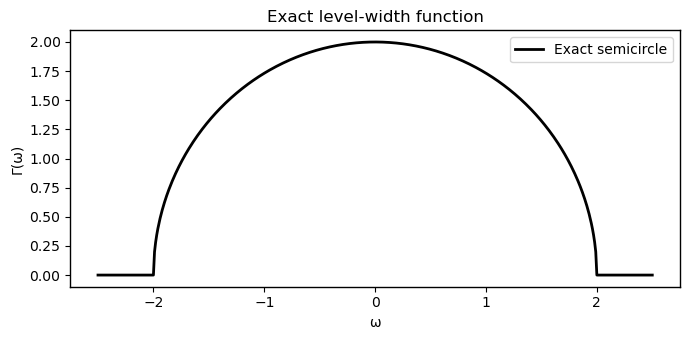

In [22]:
ωs_full = collect(-2.5:0.01:2.5)
ωs_band = collect(-1.8:0.05:1.8)

Γ_exact_full = exact_Γ.(ωs_full)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ωs_full, Γ_exact_full, "k-", lw=2, label="Exact semicircle")
ax.set_xlabel("ω")
ax.set_ylabel("Γ(ω)")
ax.set_title("Exact level-width function")
ax.legend()
plt.tight_layout()

## 2. Spectral reconstruction check

### 2a. Legacy Lorentzian fit (N=31)

The old code fits $\Gamma(\omega)$ as:
$$\Gamma_\mathrm{lor}(\omega) = \sum_{k=1}^{31} \frac{\gamma_k\, w_{0k}^2}{(\omega - \epsilon_k)^2 + w_{0k}^2}$$

Parameters from `selfenergy_1DTB_NNLS_31_pbest.csv` ($\epsilon_k$, $w_{0k}$) and `selfenergy_1DTB_NNLS_31_Ulsq.csv` ($\gamma_k$).

In [23]:
pbest = vec(readdlm(joinpath(LEGACY_DIR, "selfenergy_1DTB_NNLS_31_pbest.csv"), Float64))
ulsq  = vec(readdlm(joinpath(LEGACY_DIR, "selfenergy_1DTB_NNLS_31_Ulsq.csv"),  Float64))

eps_k = pbest[1:2:end]   # resonant level positions
w0_k  = pbest[2:2:end]   # level widths
gam_k = ulsq             # amplitudes

println("Number of Lorentzians: ", length(eps_k))
println("eps range: ", round(minimum(eps_k), digits=3), " to ", round(maximum(eps_k), digits=3))
println("w0  range: ", round(minimum(w0_k),  digits=3), " to ", round(maximum(w0_k),  digits=3))

Number of Lorentzians: 31
eps range: -1.9 to 1.868
w0  range: -0.186 to 0.123


max|Γ_lor - Γ_exact| inside band = 0.0661


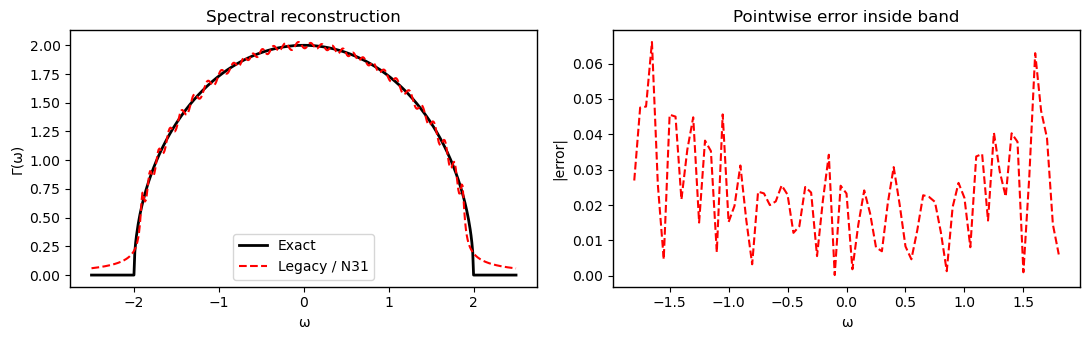

In [24]:
Γ_lor_full  = [Γ_lorentz(ω, eps_k, w0_k, gam_k) for ω in ωs_full]
Γ_lor_band  = [Γ_lorentz(ω, eps_k, w0_k, gam_k) for ω in ωs_band]
Γ_exact_band = exact_Γ.(ωs_band)

err_lor = maximum(abs.(Γ_lor_band .- Γ_exact_band))
println("max|Γ_lor - Γ_exact| inside band = ", round(err_lor, sigdigits=3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.plot(ωs_full, exact_Γ.(ωs_full), "k-",  lw=2,   label="Exact")
ax1.plot(ωs_full, Γ_lor_full,         "r--", lw=1.5, label="Legacy / N31")
ax1.set_xlabel("ω"); ax1.set_ylabel("Γ(ω)")
ax1.set_title("Spectral reconstruction")
ax1.legend()

ax2.plot(ωs_band, abs.(Γ_lor_band .- Γ_exact_band), "r--")
ax2.set_xlabel("ω"); ax2.set_ylabel("|error|")
ax2.set_title("Pointwise error inside band")

plt.tight_layout()


### 2b. MiniPoleRf rational approximation (N49)

The new code uses the symmetric rational approximation:
$$G_\mathrm{rec}(\omega) = \sum_\lambda \left[\frac{R_\lambda}{\omega - z_\lambda} + \frac{\bar{R}_\lambda}{\omega - \bar{z}_\lambda}\right], \quad \Gamma_\mathrm{rec}(\omega) = \mathrm{Re}\, G_\mathrm{rec}(\omega)$$

**Semicircle N49** (`z_Semicircle_N49.txt`, `R_Semicircle_N49.txt`): independent MiniPoleRf rational approximation of the semicircle, distinct from the Lorentzian N31 fit.


In [25]:
const N_λ2 = 20   # Pade poles for Fermi function

# Load N49 poles (MiniPoleRf semicircle — independent from the Lorentzian fit)
Rλ_N49, zλ_N49 = load_poles_square(49, N_λ2)
Rλ1_N49 = Rλ_N49[1:49]
zλ1_N49 = zλ_N49[1:49]

println("N49 poles — Re(z) range: ", round(minimum(real.(zλ1_N49)), digits=3),
        " to ", round(maximum(real.(zλ1_N49)), digits=3))
println("N49 poles — Im(z) range: ", round(minimum(imag.(zλ1_N49)), digits=3),
        " to ", round(maximum(imag.(zλ1_N49)), digits=3))


N49 poles — Re(z) range: -12.299 to 12.299
N49 poles — Im(z) range: -1.972 to -0.006


max|Γ_legacy - Γ_exact| inside band = 0.0661  (same as N31 by construction)
max|Γ_N49   - Γ_exact| inside band = 0.0049


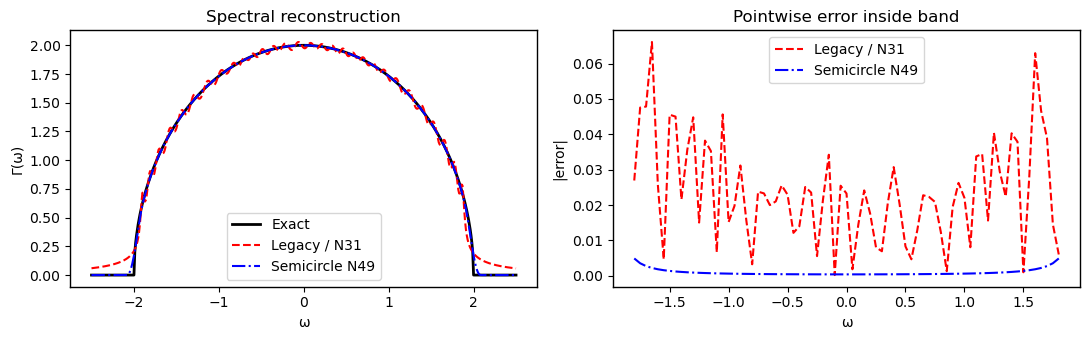

In [26]:
Γ_N49_full  = [Γ_pole(ω, Rλ1_N49, zλ1_N49) for ω in ωs_full]
Γ_N49_band  = [Γ_pole(ω, Rλ1_N49, zλ1_N49) for ω in ωs_band]

err_N49 = maximum(abs.(Γ_N49_band .- Γ_exact_band))
println("max|Γ_legacy - Γ_exact| inside band = ", round(err_lor, sigdigits=3), "  (same as N31 by construction)")
println("max|Γ_N49   - Γ_exact| inside band = ", round(err_N49, sigdigits=3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.plot(ωs_full, exact_Γ.(ωs_full), "k-",  lw=2,   label="Exact")
ax1.plot(ωs_full, Γ_lor_full,         "r--", lw=1.5, label="Legacy / N31")
ax1.plot(ωs_full, Γ_N49_full,         "b-.", lw=1.5, label="Semicircle N49")
ax1.set_xlabel("ω"); ax1.set_ylabel("Γ(ω)")
ax1.set_title("Spectral reconstruction")
ax1.legend()

ax2.plot(ωs_band, abs.(Γ_lor_band .- Γ_exact_band), "r--", label="Legacy / N31")
ax2.plot(ωs_band, abs.(Γ_N49_band .- Γ_exact_band), "b-.", label="Semicircle N49")
ax2.set_xlabel("ω"); ax2.set_ylabel("|error|")
ax2.set_title("Pointwise error inside band")
ax2.legend()

plt.tight_layout()


## 3. Pole locations in the complex plane

All poles must have $\mathrm{Im}(z) < 0$ so that the modes $e^{-i z t}$ decay for $t > 0$.

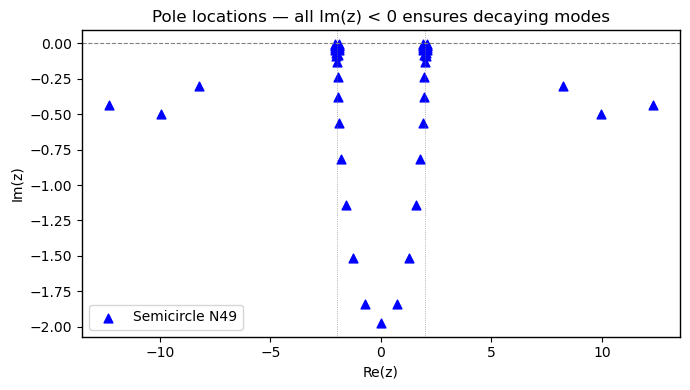

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(real.(zλ1_N49), imag.(zλ1_N49), marker="^", s=40, color="blue", label="Semicircle N49")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(-2, color="gray", lw=0.5, ls=":")
ax.axvline( 2, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Re(z)"); ax.set_ylabel("Im(z)")
ax.set_title("Pole locations — all Im(z) < 0 ensures decaying modes")
ax.legend()
plt.tight_layout()


## 4. Time-domain check: $\Sigma^<(t)$ via residue theorem vs direct FT

For $t \geq 0$, closing the contour in the lower half-plane:
$$\Sigma^<(t) = \int\frac{d\omega}{2\pi}\,f(\omega)\,\Gamma(\omega)\,e^{-i\omega t}
             = -i \sum_\lambda \Sigma^L_{n\lambda}\, e^{-i\chi_{n\lambda} t}$$

The `build_Σᴸ_nλ` and `build_χ_nλ` functions in TDNEGF construct $\Sigma^L_{n\lambda}$ and $\chi_{n\lambda}$ from the pole data. This check verifies they are correct.

In [31]:
using .SelfEnergySquare: build_Σᴸ_nλ, build_Σᴳ_nλ,
                             build_χ_nλ, build_ξ_an, build_ξ_local_index

In [37]:
const β   = 33.0    # inverse temperature
const Ny  = 1       # 1D lead: single transverse mode, epsilon_n = 0
const Nσ  = 2       # spin degeneracy
const Norb = 1
const t_grid = collect(0.0:0.5:200.0)

# Reference: direct numerical FT (same for all pole sets since it uses the exact Gamma)
ΣL_direct = [ΣL_direct_ft(t; β=β) for t in t_grid]

println("ΣL_direct(t=0) = ", round(real(ΣL_direct[1]), sigdigits=4),
        " + i", round(imag(ΣL_direct[1]), sigdigits=4))

ΣL_direct(t=0) = 0.5 + i0.0


In [38]:
# Build auxiliary-state matrices for N49
ΣL_nλ_N49 = build_Σᴸ_nλ(Rλ_N49, zλ_N49, Ny, Nσ, Norb, 49, N_λ2; β=β, γ=1.0)
χ_nλ_N49  = build_χ_nλ( zλ_N49,         Ny, Nσ, Norb, 49, N_λ2; β=β, γ=1.0)

println("ΣL_nλ size: ", size(ΣL_nλ_N49), "   χ_nλ size: ", size(χ_nλ_N49))


ΣL_nλ size: (2, 69)   χ_nλ size: (2, 69)


In [39]:
# Pole sum for channel n=1 (both channels identical for 1D since epsilon_n = 0)
n = 1
ΣL_poles_N49 = [ΣL_pole_sum(t, n, ΣL_nλ_N49, χ_nλ_N49) for t in t_grid]

println("rel_rmse N49 = ", round(rel_rmse(ΣL_poles_N49, ΣL_direct), sigdigits=3))


rel_rmse N49 = 0.0105


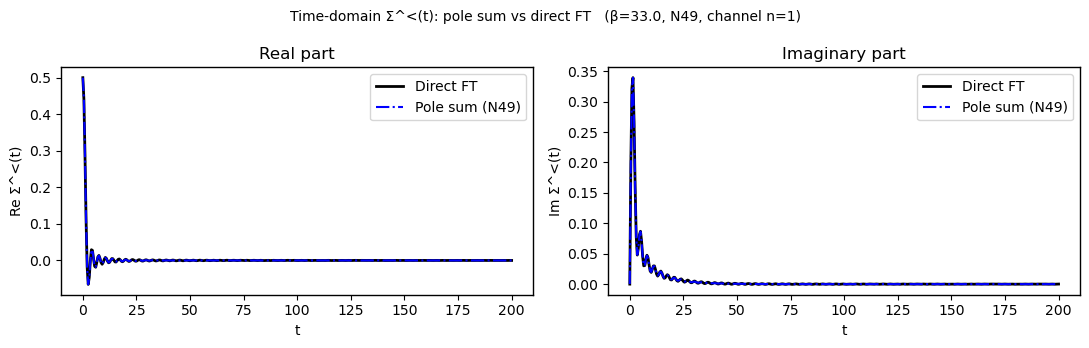

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.plot(t_grid, real.(ΣL_direct),    "k-",  lw=2,   label="Direct FT")
ax1.plot(t_grid, real.(ΣL_poles_N49), "b-.", lw=1.5, label="Pole sum (N49)")
ax1.set_xlabel("t"); ax1.set_ylabel("Re Σ^<(t)")
ax1.set_title("Real part")
ax1.legend()

ax2.plot(t_grid, imag.(ΣL_direct),    "k-",  lw=2,   label="Direct FT")
ax2.plot(t_grid, imag.(ΣL_poles_N49), "b-.", lw=1.5, label="Pole sum (N49)")
ax2.set_xlabel("t"); ax2.set_ylabel("Im Σ^<(t)")
ax2.set_title("Imaginary part")
ax2.legend()

plt.suptitle("Time-domain Σ^<(t): pole sum vs direct FT   (β=$β, N49, channel n=$n)", fontsize=10)
plt.tight_layout()


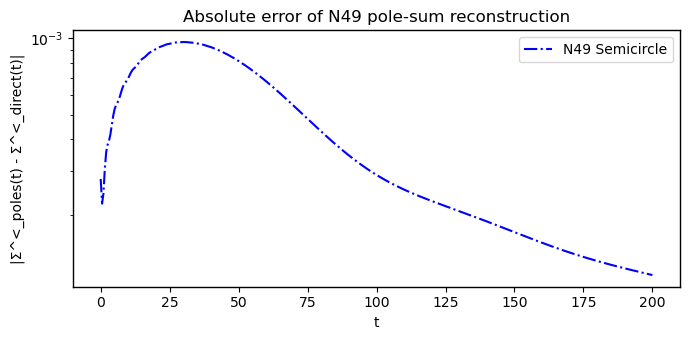

In [41]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(t_grid, abs.(ΣL_poles_N49 .- ΣL_direct), "b-.", lw=1.5, label="N49 Semicircle")
ax.set_xlabel("t")
ax.set_ylabel("|Σ^<_poles(t) - Σ^<_direct(t)|")
ax.set_title("Absolute error of N49 pole-sum reconstruction")
ax.legend()
plt.tight_layout()


## 5. Time-domain check for legacy / N31

Same check as for N49, but using $\Gamma_\mathrm{lor}(\omega)$ instead of $\Gamma_\mathrm{exact}(\omega)$ in the integrand:
$$\Sigma^<_\mathrm{lor}(t) = \int\frac{d\omega}{2\pi}\,f(\omega)\,\Gamma_\mathrm{lor}(\omega)\,e^{-i\omega t}$$

Both are compared against the exact reference FT. The difference between them reflects how much the spectral fit error propagates to the time domain.


In [42]:
# Direct FT using Gamma_lor (legacy fit) instead of Gamma_exact
function ΣL_lorentz_ft(t; β, eps, w0, gam, ω_max=8.0, dω=0.005)
    ωs = -ω_max:dω:ω_max
    integrand = [fermi(ω; β=β) * Γ_lorentz(ω, eps, w0, gam) * exp(-1im * ω * t) for ω in ωs]
    return (dω / (2π)) * (sum(integrand) - 0.5 * (integrand[1] + integrand[end]))
end

ΣL_lor_td = [ΣL_lorentz_ft(t; β=β, eps=eps_k, w0=w0_k, gam=gam_k) for t in t_grid]

println("rel_rmse(Σ^<_lor, Σ^<_exact) = ",
        round(rel_rmse(ΣL_lor_td, ΣL_direct), sigdigits=3))
println("rel_rmse(Σ^<_N49, Σ^<_exact) = ",
        round(rel_rmse(ΣL_poles_N49, ΣL_direct), sigdigits=3))


rel_rmse(Σ^<_lor, Σ^<_exact) = 0.0435
rel_rmse(Σ^<_N49, Σ^<_exact) = 0.0105


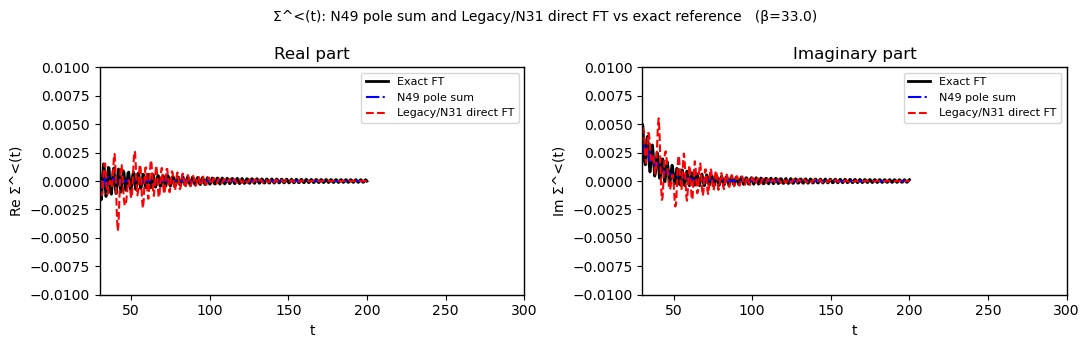

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.plot(t_grid, real.(ΣL_direct),    "k-",  lw=2,   label="Exact FT")
ax1.plot(t_grid, real.(ΣL_poles_N49), "b-.", lw=1.5, label="N49 pole sum")
ax1.plot(t_grid, real.(ΣL_lor_td),    "r--", lw=1.5, label="Legacy/N31 direct FT")
ax1.set_xlabel("t"); ax1.set_ylabel("Re Σ^<(t)")
ax1.set_title("Real part")
ax1.legend(fontsize=8)
ax1.set_ylim(-0.01,0.01)
ax1.set_xlim(30,300)

ax2.plot(t_grid, imag.(ΣL_direct),    "k-",  lw=2,   label="Exact FT")
ax2.plot(t_grid, imag.(ΣL_poles_N49), "b-.", lw=1.5, label="N49 pole sum")
ax2.plot(t_grid, imag.(ΣL_lor_td),    "r--", lw=1.5, label="Legacy/N31 direct FT")
ax2.set_xlabel("t"); ax2.set_ylabel("Im Σ^<(t)")
ax2.set_title("Imaginary part")
ax2.legend(fontsize=8)


plt.suptitle("Σ^<(t): N49 pole sum and Legacy/N31 direct FT vs exact reference   (β=$β)", fontsize=10)

ax2.set_ylim(-0.01,0.01)
ax2.set_xlim(30,300)
plt.tight_layout()


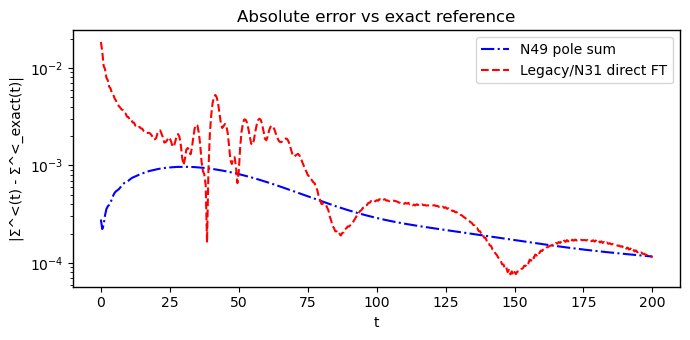

In [54]:
# Absolute error comparison
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(t_grid, abs.(ΣL_poles_N49 .- ΣL_direct), "b-.", lw=1.5, label="N49 pole sum")
ax.semilogy(t_grid, abs.(ΣL_lor_td    .- ΣL_direct), "r--", lw=1.5, label="Legacy/N31 direct FT")
ax.set_xlabel("t")
ax.set_ylabel("|Σ^<(t) - Σ^<_exact(t)|")
ax.set_title("Absolute error vs exact reference")
ax.legend()
plt.tight_layout()
